# **AI-Powered Medical Data Preprocessing Agent**

### **From Messy Clinical Records to Reliable Time-Series Intelligence**

**PyCon Kenya 2026 - "From Messy Data to Clean Insights: Building AI-Powered Data Preprocessing Agents with Python"**

This notebook is the complete, executable companion to the talk. It takes a deliberately
messy synthetic hospital admission dataset and turns it into a validated, model-ready
hourly clinical time series - under the control of an agent that plans its own work,
executes deterministic Python tools, checks its results against stated postconditions,
repairs what it can, and halts when it cannot.

The argument the notebook is making is narrow and worth stating up front:

> **An AI agent should not clean data by improvising. It should reason about the problem,
> execute controlled Python transformations, validate the results against conditions
> declared in advance, and leave an audit trail a human can check.**

Everything below is organised around making that claim falsifiable. Every number in
the prose is computed in a cell you can re-run. Every transformation produces an audit
record. At the end, an independent validation agent re-derives all of it from the data
rather than trusting the audits, and prints a verdict.

### How to read this notebook

| Section | What it covers |
|---|---|
| 1–2 | The clinical problem, and environment setup |
| 3 | The synthetic dataset and why it is synthetic |
| 4–5 | The profiling agent, and what the defects look like |
| 6 | The agent architecture: plan → act → observe → validate → refine |
| 7–10 | The cleaning tools, one per defect class |
| 11 | Event data → hourly time series (where missingness becomes visible) |
| 12 | Value–Mask–Decay: the representation at the heart of the project |
| 13 | DeepTSE-inspired refinement, and an honest benchmark against LOCF |
| 14 | The validation agent and the reports |
| 15 | The dashboard |
| 16 | Limits, responsible use, and when *not* to use an agent |

**Runtime:** roughly 30 seconds end to end on a laptop. No API key is required.

## 1. Introduction

### 1.1 The problem

Most published work on clinical machine learning begins after the hard part is over.
The dataset arrives as a rectangular matrix with a row per patient-hour and a column per
variable, and the paper proceeds to architecture. Practitioners know that this matrix does
not exist in nature. What exists is an export from a hospital information system: an
irregular log of events, recorded by different people on different devices at whatever
moments clinical attention happened to fall.

Four properties of that export defeat naive preprocessing.

**Observations are irregular.** A patient admitted at 08:00 and discharged three days
later does not generate a measurement every hour. They generate a cluster of measurements
on admission, a few during each nursing round, a dense burst if they deteriorate, and
nothing at all overnight if they are stable. The gaps are not missing data in the
statistical sense — they are the absence of a decision to measure.

**Missingness is informative.** Because measurement is a clinical decision, the pattern
of what was measured carries information about the patient. A channel recorded every
fifteen minutes belongs to someone being watched closely. Imputing the gaps and discarding
the record of where they were throws away a signal that is often as predictive as the
values themselves.

**Units and formats are inconsistent.** Temperature arrives in Celsius from one ward and
Fahrenheit from another. Glucose arrives in mg/dL and mmol/L. Timestamps arrive in four
spellings, one of which - `DD/MM/YYYY` - is silently misread by every default date parser
in the Python ecosystem.

**Errors look like data.** A saturation probe that has slipped off reports 120%. A
transcription slip turns 48 into 480. These are not outliers to be winsorised; they are
absences wearing the costume of measurements.

### 1.2 Why an agent, rather than a script

None of the above requires an LLM. A competent analyst with a fixed schema should write a
deterministic script, and this notebook says so explicitly in §16.

The case for an agent is narrower: it is about the *exploration* phase, where the schema
is not yet fixed, where you receive a new export every month from a different hospital
system, and where the first hour of work is spent finding out what is wrong before any of
it can be fixed. An agent that profiles a file, selects a plan from a catalogue of
transformations, and produces an audit trail compresses that first hour into a few seconds
and makes the result reviewable.

The critical design decision — and the one that separates this project from a
copy-the-CSV-into-a-chatbot workflow — is that **the data never leaves the machine**. Only a
compact statistical profile is used for reasoning. Python performs every transformation
locally.

### 1.3 What gets built

$$
\text{messy CSV} \;\rightarrow\; \text{profile} \;\rightarrow\; \text{plan} \;\rightarrow\;
\text{execute} \;\rightarrow\; \text{validate} \;\rightarrow\;
\underbrace{(v_t,\; m_t,\; d_t)}_{\text{Value–Mask–Decay}} \;\rightarrow\; \text{refine} \;\rightarrow\; \text{report}

## 2. Environment setup

The project is organised as a package rather than a single notebook, because the code
that transforms clinical data should be testable, reviewable and importable independently
of the document that explains it. The notebook is the *narrative layer*; the modules are
the engineering.

```
Medical_AI_Preprocessing_Agent/
├── Medical_AI_Preprocessing_Agent.ipynb   ← this document
├── config.py                              ← paths, schema, ranges, palette
├── run_pipeline.py                        ← headless end-to-end runner
├── agents/         preprocessing_agent · validation_agent · tool_registry · llm_planner
├── preprocessing/  synthetic_data · data_profiler · duplicate_handler · date_cleaner
│                   unit_converter · categorical_cleaner · range_validator
│                   missing_value_handler · timeseries_builder
├── models/         deeptse_imputer
├── visualization/  plots · dashboard
├── tests/          test_pipeline.py  (29 regression tests)
├── data/  reports/  outputs/figures/
```

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

# Make the project importable whether the notebook is run from its own directory,
# from a parent directory, or from Google Colab.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config.py").exists():
    for candidate in [PROJECT_ROOT.parent, *PROJECT_ROOT.parents]:
        if (candidate / "config.py").exists():
            PROJECT_ROOT = candidate
            break
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

import config
from visualization import plots

plots.apply_house_style()

print(f"Project root : {PROJECT_ROOT}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"Random seed  : {config.RANDOM_SEED}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\ADMIN\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\ADMIN\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\ADMIN\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\ADMIN\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found

Project root : c:\Users\ADMIN\OneDrive\Desktop\Data Science\Projects\Medical_AI_Preprocessing_Agent
pandas       : 3.0.2
numpy        : 2.4.4
Random seed  : 2026


### 2.1 Choosing the input file

Two raw datasets ship with the project.

| File | Origin |
|---|---|
| `raw_hospital_admission_data.csv` | Generated by `preprocessing/synthetic_data.py`, calibrated to the published defect rates. **Default.** |
| `raw_hospital_admission_medical_data_original.csv` | The author's earlier hand-built file, kept for provenance. |

The original file has three generation defects that would distort the demonstration: it
contains **no duplicate rows** (so the deduplication step has nothing to show), its
"invalid value" injection replaced roughly 30% of several channels with a single constant
(`heart_rate == 300.0`, `mbp == "85 mmHg"`), and those constants destroy the underlying
measurement rather than disguising it, so unit conversion cannot be scored for correctness.

The calibrated generator fixes all three while keeping every defect class the brief asks
for. Both files run through the identical pipeline — flip the flag below to compare.

**A warning worth reading before you flip it.** Setting `USE_ORIGINAL_CSV = True` makes the
agent **halt** at §6.5. This is not a bug in the notebook; it is the safety rail working.
Because roughly 30% of `heart_rate`, `spo2` and `age` in the original file are a single
sentinel constant, range validation removes more than half of those channels, the
`no_channel_lost_the_majority_of_its_observations` postcondition fails, and the agent
refuses to emit a dataset it cannot vouch for:

```
spo2         595 ->  290   lost 51.3%
heart_rate   572 ->  288   lost 49.7%
age          665 ->  342   lost 48.6%
```

The agent reaches that verdict on its own, from the data, without being told which file it
is looking at. If you want to see the halt, §16.1 demonstrates it deliberately and handles
it.

In [2]:
USE_ORIGINAL_CSV = False   # set True to run the author's original file through the same pipeline

from preprocessing.synthetic_data import write_raw_dataset

if USE_ORIGINAL_CSV:
    RAW_PATH = config.RAW_CSV_ORIGINAL
    GROUND_TRUTH = None
    print(f"Using the original file: {RAW_PATH.name}")
else:
    _, GROUND_TRUTH = write_raw_dataset(seed=config.RANDOM_SEED)
    RAW_PATH = config.RAW_CSV
    print(f"Generated calibrated dataset: {RAW_PATH.name}")

raw = pd.read_csv(RAW_PATH, dtype=str)
print(f"Loaded {len(raw):,} rows x {raw.shape[1]} columns")

Generated calibrated dataset: raw_hospital_admission_data.csv
Loaded 1,000 rows x 24 columns


---
## 3. The dataset

### 3.1 Why synthetic

Real intensive-care records cannot be redistributed, and a conference demonstration needs
a dataset whose defects are known in advance. Synthetic data buys three things that matter
more than realism:

1. **Ground truth about the defects.** We know exactly how many duplicates and Fahrenheit
   readings were injected, so the pipeline's *recovery rate* can be measured. No real
   dataset permits this.
2. **Reproducibility.** A seed regenerates the file byte for byte, so every number in this
   notebook can be independently reproduced.
3. **No privacy exposure.** Nothing here corresponds to a person.

The generator is nonetheless careful about one thing that matters for the science: every
injected defect **preserves the underlying true value where one exists**. A Fahrenheit
temperature is the real Celsius reading converted; a `"mmHg"` string is the real pressure
with a suffix. Without that property, "the pipeline converted 404 temperatures" would be a
statement about string handling rather than about correctness.

### 3.2 The data model

Each row is **one clinical observation event** — not a patient, and not an hour.

| Group | Columns | Role |
|---|---|---|
| Admission | `admission_id`, `patient_id`, `intime`, `outtime`, `charttime` | Define the monitoring window and when each measurement was taken |
| Demographics | `age`, `gender`, `ethnicity` | Static context; carry injected category noise and impossible ages |
| Vital signs | `heart_rate`, `sbp`, `dbp`, `mbp`, `temperature`, `spo2`, `resp_rate`, `glucose` | The eight channels that become the time series |
| Laboratory | `creatinine`, `wbc_count`, `platelet_count` | Slower-moving context |
| Clinical context | `admission_type`, `diagnosis`, `medication`, `sofa_score`, `data_source` | Categorical fields with free-text variation |

The distinction between `intime` and `charttime` is the structural key to the whole
project. `intime` is when the patient arrived; `charttime` is when somebody happened to
take a reading. The admission window says how many hours the patient was present; the
chart times say how few of those hours were measured. The difference between those two
numbers *is* the missing-data problem.

In [3]:
print("Shape:", raw.shape)
display(raw.head(6))

print("\nAdmission ADM0001, as recorded:")
display(raw[raw["admission_id"] == "ADM0001"][
    ["patient_id", "intime", "outtime", "charttime", "heart_rate", "sbp", "temperature", "spo2"]
].head(10))

Shape: (1000, 24)


,admission_id,patient_id,intime,outtime,charttime,age,gender,ethnicity,heart_rate,sbp,dbp,mbp,temperature,spo2,resp_rate,glucose,creatinine,wbc_count,platelet_count,admission_type,diagnosis,medication,sofa_score,data_source
0,ADM0028,P028,2026-01-12 23:00,2026-01-15 04:00,Jan 14 2026 11:49,66.0,Female,african-american,89.6,NaN,54.9,70.3,37.6 C,92.4,19.7,119.2,1.5,14.53,NaN,Ward,Cardiac,Vasopressor,10.0,laboratory
1,ADM0015,P015,2026-02-03 18:00,2026-02-05 20:00,2026/02/05 17:45,65.0,Male,other,81.0,130.7,69.9,99.1,98.4 F,92.5,16.9,NaN,1.96,10.42,NaN,icu,pneumonia,Insulin,3.0,Nurse Entry
2,ADM0067,P067,15/01/2026 22:00,18/01/2026 08:00,2026/01/16 17:05,19.0,Female,Other,109.1,126.4,NaN,91.0 mmHg,100.2 F,93.6,23.7,115.7,2.16,NaN,NaN,ward,sepsis,Antibiotic,20.0,nurse entry
3,ADM0016,P016,2026/01/27 00:00,2026/01/28 07:00,Jan 27 2026 01:14,85.0,male,African,91.6,106.6,63.5,NaN,37.5 C,94.9,23.8,120.8,2.5,8.57,211.5,ER,Cardiac Failure,Vasopressor,16.0,Nurse entry
4,ADM0027,P027,Jan 29 2026 07:00,Jan 31 2026 08:00,2026-01-30 06:50,42.0,Male,Other,113.5,110.9,74.5,82.9 mmHg,61.0 C,93.8,23.4,148.5,2.5,12.58,270.35,emergency,SEPSIS,Antibiotic,17.0,Nurse entry
5,ADM0017,P017,2026-01-28 13:00,2026-01-29 21:00,2026/01/29 06:30,47.0,Male,Other,87.5,0.0,77.3,90.0,37.7 C,95.4,15.9,NaN,1.99,NaN,256.87,icu,Trauma,insulin,14.0,Monitor



Admission ADM0001, as recorded:


,patient_id,intime,outtime,charttime,heart_rate,sbp,temperature,spo2
14,P001,09/01/2026 06:00,11/01/2026 12:00,2026/01/10 00:27,480.0,117.5,37.6 C,NaN
86,P001,09/01/2026 06:00,11/01/2026 12:00,2026-01-09 16:51,83.9,115.7,37.7 C,140.0
166,P001,09/01/2026 06:00,11/01/2026 12:00,10/01/2026 17:38,78.3,112.4,99.7 F,94.3
229,P001,09/01/2026 06:00,11/01/2026 12:00,Jan 10 2026 01:51,80.9,112.3,NaN,94.2
556,P001,09/01/2026 06:00,11/01/2026 12:00,2026/01/10 05:20,83.5,120.9,37.6 C,94.5
692,P001,09/01/2026 06:00,11/01/2026 12:00,2026-01-10 10:22,82.3,NaN,99.7 F,93.3


Even in ten rows the defects are visible: the same admission window is written in more than
one spelling, temperatures carry different unit letters, and several cells are empty. The
next section quantifies all of it.

In [4]:
if GROUND_TRUTH:
    print("GROUND TRUTH — defects injected by the generator\n" + "-" * 52)
    print(f"  Duplicate rows          : {GROUND_TRUTH['duplicate_rows_injected']:,}")
    print(f"  Fahrenheit temperatures : {GROUND_TRUTH['fahrenheit_cells']:,}")
    print(f"  Unit-suffixed cells     : {GROUND_TRUTH['unit_suffix_cells']:,}")
    print(f"  Impossible values       : {GROUND_TRUTH['impossible_cells']:,}")
    print(f"  Category variant cells  : {GROUND_TRUTH['category_noise_cells']:,}")
    print("\n  Datetime spellings used:")
    for spelling, count in GROUND_TRUTH["date_spellings"].items():
        print(f"    {spelling:<22} {count:>5,}")
else:
    print("Ground truth is unavailable for the original file (its generator manifest was not kept).")

GROUND TRUTH — defects injected by the generator
----------------------------------------------------
  Duplicate rows          : 100
  Fahrenheit temperatures : 404
  Unit-suffixed cells     : 360
  Impossible values       : 457
  Category variant cells  : 1,819

  Datetime spellings used:
    %Y-%m-%d %H:%M           299
    %Y/%m/%d %H:%M           319
    %d/%m/%Y %H:%M           269
    %b %d %Y %H:%M           313


---
## 4. The data profiling agent

### 4.1 Perception before planning

An agent cannot plan a strategy it cannot describe. Profiling is the agent's perception
step, and its design is governed by a constraint that shapes the entire architecture:

> The profile must be small enough to reason over, and complete enough to plan from.

For this 1,000-row, 24-column file the profile renders to roughly **1.5 kB of text**. The
file itself is 160 kB. That ratio is the entire technical argument for agent-guided
preprocessing: an LLM can reason about the *description* of a dataset it could never fit
in its context window, and at no point does a patient record cross the network.

The profiler is deliberately **diagnostic, not prescriptive**. It reports that four
datetime spellings are present; deciding what to do about that belongs to the planner.

In [5]:
from preprocessing.data_profiler import profile_data, format_profile

profile_before = profile_data(raw)
print(format_profile(profile_before))

DATASET PROFILE
  Rows: 1,000    Columns: 24
  Exact duplicate rows: 100

  Missing values (top 10):
    wbc_count            282 (28.2%)
    glucose              216 (21.6%)
    dbp                  202 (20.2%)
    creatinine           200 (20.0%)
    sbp                  194 (19.4%)
    heart_rate           166 (16.6%)
    platelet_count       162 (16.2%)
    resp_rate            160 (16.0%)
    mbp                  148 (14.8%)
    temperature          145 (14.5%)

  Datetime spellings detected:
    intime       4 format(s): ISO=312, Slash ISO=169, Day-first=260, Month name=259
    outtime      4 format(s): ISO=312, Slash ISO=169, Day-first=260, Month name=259
    charttime    4 format(s): ISO=237, Slash ISO=290, Day-first=210, Month name=263

  Mixed unit tokens:
    sbp                <bare number>=713, mmHg=93
    mbp                <bare number>=770, mmHg=82
    temperature        C=528, F=327
    glucose            <bare number>=682, mmol/L=102

  Implausible / unparseable cells

In [6]:
profile_text = format_profile(profile_before)
print(f"Raw CSV on disk : {RAW_PATH.stat().st_size / 1024:6.1f} kB")
print(f"Profile text    : {len(profile_text.encode('utf-8')) / 1024:6.1f} kB")
print(f"Compression     : {RAW_PATH.stat().st_size / len(profile_text.encode('utf-8')):6.0f}x")
print("\nThis is what the planner reasons over. The rows never leave the machine.")

Raw CSV on disk :  177.6 kB
Profile text    :    2.0 kB
Compression     :     87x

This is what the planner reasons over. The rows never leave the machine.


### 4.2 Reading the profile

Three entries deserve comment before we go further.

**Four datetime spellings, in all three timestamp columns.** One of them is `DD/MM/YYYY`.
Section 8 shows what default parsing does to it.

**`temperature` reports hundreds of cells out of physiological range.** That is not a
temperature problem — it is a *unit* problem. Fahrenheit values sit far outside the
plausible Celsius band, so the range check flags them. This is exactly why the tool
catalogue declares that unit conversion must precede range validation: run them in the
wrong order and the pipeline deletes several hundred perfectly good measurements. The
agent enforces that dependency in §6.

**Categorical columns have more distinct raw values than case-folded ones.** That is the
signature of free-text variation: `Emergency`, `emergency`, `ER` and `Emergency Admission`
are one category recorded by four people.

---
## 5. What the defects look like

Numbers in a profile are easy to skim past. These three figures make the same information
hard to ignore.

Throughout the notebook the visual convention is fixed: **orange is the state before a
transformation, blue is the state after**, and a third series, where unavoidable, is aqua
and always carries a direct label.

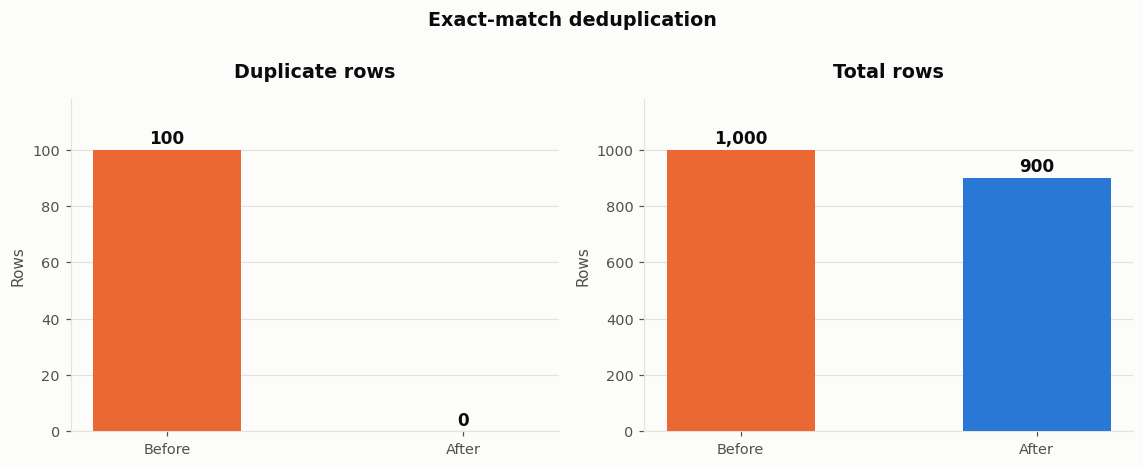

100 of 1,000 rows (10.0%) are exact duplicates.


In [7]:
duplicate_count = profile_before["duplicates"]["exact_duplicate_rows"]
fig = plots.plot_duplicate_comparison(
    duplicates_before=duplicate_count,
    duplicates_after=0,
    rows_before=len(raw),
    rows_after=len(raw) - duplicate_count,
)
plt.show()

print(f"{duplicate_count:,} of {len(raw):,} rows ({100 * duplicate_count / len(raw):.1f}%) are exact duplicates.")

A duplicated observation is not a cosmetic problem. It doubles that patient-hour's weight
in any loss function, and it biases every population statistic computed from the table.

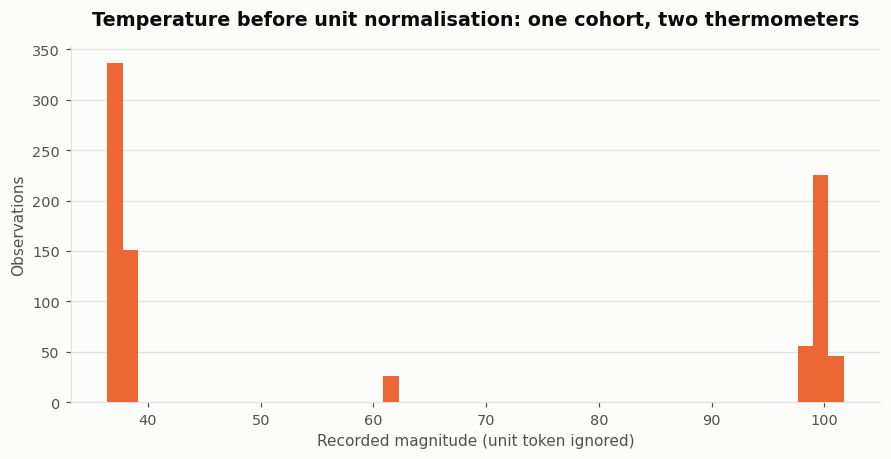

Values in the Celsius band (30-45)      : 487
Values in the Fahrenheit band (90-110)  : 327

A model trained on this column would learn a 'cohort' that is an artefact of thermometer firmware.


In [8]:
raw_temperature_magnitude = raw["temperature"].astype(str).str.extract(r"(-?\d+\.?\d*)", expand=False)
raw_temperature_magnitude = pd.to_numeric(raw_temperature_magnitude, errors="coerce")

fig = plots.plot_temperature_unit_problem(
    raw_values=raw_temperature_magnitude,
    converted_values=raw_temperature_magnitude,  # placeholder: the converted panel is drawn again in §9
    save_as=None,
)
plt.close(fig)

plausible = raw_temperature_magnitude.dropna()
plausible = plausible[plausible.between(20, 120)]
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.hist(plausible, bins=48, color=config.PALETTE["series_2"], zorder=3)
ax.set_title("Temperature before unit normalisation: one cohort, two thermometers")
ax.set_xlabel("Recorded magnitude (unit token ignored)")
ax.set_ylabel("Observations")
ax.grid(axis="x", visible=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.show()

celsius_like = int(plausible.between(30, 45).sum())
fahrenheit_like = int(plausible.between(90, 110).sum())
print(f"Values in the Celsius band (30-45)      : {celsius_like:,}")
print(f"Values in the Fahrenheit band (90-110)  : {fahrenheit_like:,}")
print("\nA model trained on this column would learn a 'cohort' that is an artefact of thermometer firmware.")

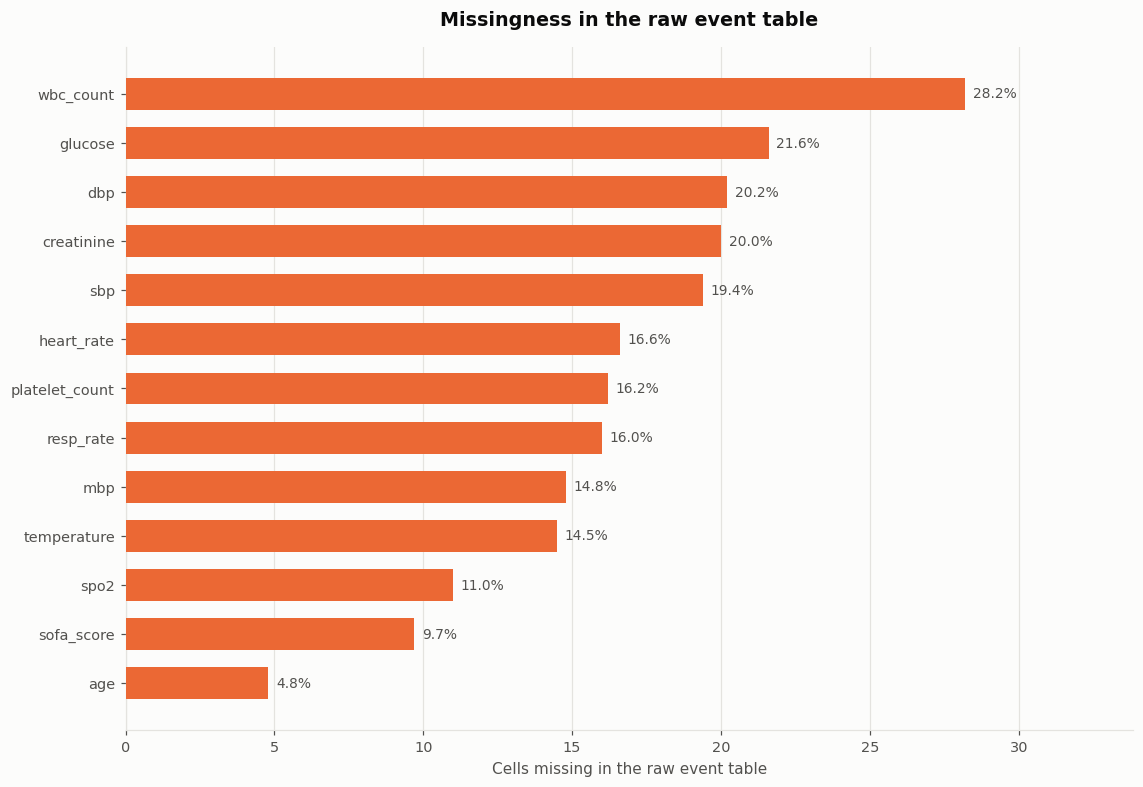

Keep these numbers in mind. Section 11 shows they are a substantial underestimate.


In [9]:
missing_pct = pd.Series(profile_before["missing_pct"])
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(missing_pct) + 1.8))
bars = ax.barh(missing_pct.index[::-1], missing_pct.values[::-1],
               color=config.PALETTE["series_2"], height=0.65, zorder=3)
for bar, value in zip(bars, missing_pct.values[::-1]):
    ax.annotate(f"{value:.1f}%", (value, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", va="center",
                fontsize=9, color=config.PALETTE["text_secondary"])
ax.set_xlabel("Cells missing in the raw event table")
ax.set_xlim(0, missing_pct.max() * 1.2)
ax.set_title("Missingness in the raw event table")
ax.grid(axis="y", visible=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print("Keep these numbers in mind. Section 11 shows they are a substantial underestimate.")

---
## 6. The cleaning agent

### 6.1 Architecture

An agent is an LLM for reasoning plus tools for acting. This project separates the two
cleanly, and the separation is the point.

```
                        ┌──────────────────────┐
     raw CSV  ─────────▶│   PROFILING AGENT    │  perception: 160 kB → 1.5 kB
                        └──────────┬───────────┘
                                   │  profile
                                   ▼
                        ┌──────────────────────┐
                        │       PLANNER        │  RuleBasedPlanner  (default, offline)
                        │     (the "brain")    │  LLMPlanner        (optional, LiteLLM)
                        └──────────┬───────────┘
                                   │  plan: [tool, reason] ...
                                   ▼
        ┌──────────────────────────────────────────────────────┐
        │                    AGENT LOOP                        │
        │   ACT ─▶ OBSERVE ─▶ VALIDATE ─▶ (REFINE if failed)   │
        └──────────────────────────┬───────────────────────────┘
                                   │  calls, one at a time
                                   ▼
                        ┌──────────────────────┐
                        │    TOOL REGISTRY     │  8 deterministic pandas tools
                        │    (the "hands")     │  each returns (frame, audit)
                        └──────────┬───────────┘
                                   ▼
                        ┌──────────────────────┐
                        │  VALIDATION AGENT    │  re-derives every claim from the data
                        └──────────────────────┘
```

### 6.2 Two design decisions worth defending

**The planner never writes code.** It selects tool names and arguments from a fixed
catalogue. This is a deliberate departure from the CodeAct pattern used in the reference
implementation this project builds on, where the model writes arbitrary pandas constrained
by an import allow-list. That approach is more general and better suited to exploration.
A closed action space is better suited to clinical data, because it can be reviewed
*before* it runs rather than audited afterwards, and a hallucinated tool name produces a
rejection instead of an exception. §16 returns to this trade-off.

**Every tool returns an audit.** Each has the signature `frame → (frame, audit)`. The agent
accumulates a structured record of what happened without any tool needing to know that an
agent exists — the same functions are directly callable from a plain script.

### 6.3 The tool catalogue

This is the complete set of actions available to the agent. There is no other way for it
to affect the data.

In [10]:
from agents.tool_registry import describe_tools, TOOL_REGISTRY, CANONICAL_ORDER

print(describe_tools())
print(f"\n{len(TOOL_REGISTRY)} tools available. Anything outside this list is rejected before execution.")

remove_duplicates [clean]
  Drop exactly duplicated observation rows and record the original row index of every row removed.
  requires: Raw event table as loaded from CSV.
  produces: Event table with no exact duplicate rows.

standardise_datetimes [clean]
  Parse intime, outtime and charttime from their mixed surface formats into true timestamps, reconcile one admission window per admission_id, and derive length of stay in hours.
  requires: Duplicates removed, so that window reconciliation votes on distinct rows.
  produces: datetime64 columns plus length_of_stay_hours.

convert_units [clean]
  Normalise every measurement column to one canonical unit: temperature to Celsius, glucose to mg/dL, and strip redundant unit suffixes elsewhere.
  requires: Raw measurement columns, possibly holding unit-suffixed strings.
  produces: Float measurement columns in canonical units.

standardise_categories [clean]
  Map categorical fields onto a controlled vocabulary and list any value the vocabu

### 6.4 The planner

The default planner is deterministic: it reads the profile and justifies each tool from
evidence found there. It requires no API key and produces identical output on every run,
which is why it is the default — a conference demonstration that depends on a live API
call over conference wifi is a demonstration that fails on stage.

An `LLMPlanner` is provided and is used automatically when an API key is present. Both
return the same structure, so the agent cannot tell which it holds. **That substitutability
is the lesson:** the valuable part of an agent is the *contract* — a validated plan over a
closed catalogue — not the fact that a language model produced it.

In [11]:
from agents.llm_planner import RuleBasedPlanner, LLMPlanner, build_planner

print(f"LLM planner available : {LLMPlanner.is_available()}")
print("  (set GEMINI_API_KEY / OPENAI_API_KEY and `pip install litellm` to enable)\n")

planner = build_planner(prefer_llm=True)   # silently falls back when no key is present
print(f"Planner selected      : {planner.name}\n")

plan_steps, plan_concerns = planner.plan(profile_before)
for index, step in enumerate(plan_steps, start=1):
    print(f"{index}. {step.tool}")
    print(f"   {step.reason}\n")
for concern in plan_concerns:
    print(f"! CONCERN: {concern}")

LLM planner available : False
  (set GEMINI_API_KEY / OPENAI_API_KEY and `pip install litellm` to enable)

Planner selected      : rule_based

1. remove_duplicates
   Profile reports 100 exactly duplicated rows (10.0% of the table); each inflates its patient-hour's weight in any downstream model.

2. standardise_datetimes
   4 distinct datetime spellings detected across the timestamp columns; day-first values are ambiguous under default parsing and must be resolved by surface form.

3. convert_units
   Mixed unit tokens found (sbp: <bare number>, mmHg; mbp: <bare number>, mmHg; temperature: C, F; glucose: <bare number>, mmol/L). Range validation cannot run correctly until units agree.

4. standardise_categories
   Categorical fields carry spelling variants (worst: diagnosis with 13 raw values); unmerged variants split cohort statistics.

5. validate_ranges
   811 cells fall outside physiological bounds or cannot be parsed; these are sensor or transcription faults and must become missin

Two things to notice. Every step cites a **number from the profile** rather than a generic
justification — that is what makes the plan reviewable. And the planner raises a *concern*
about channels whose missing rate is high enough that imputation would be weakly
constrained, rather than quietly imputing them anyway. An agent that only ever reports
success is an agent that is not checking anything.

### 6.5 Running the loop

Each iteration executes one tool, reads its audit, and applies **postcondition checks** —
assertions about what that tool was supposed to achieve, written before it ran. When a
check fails the agent attempts one enumerated repair and re-checks. If the repair does not
work, it raises and stops.

Halting is the correct behaviour. The alternative is writing out a file that claims to be
clean and is not.

In [12]:
from agents.preprocessing_agent import PreprocessingAgent

agent = PreprocessingAgent(planner=planner, verbose=True)
result = agent.run(raw)

AI MEDICAL PREPROCESSING AGENT

[PERCEIVE] Profiling the raw dataset ...
           1,000 rows x 24 columns | 100 duplicate rows | 4 columns with mixed units

[PLAN] Planner: rule_based
       1. remove_duplicates
          why: Profile reports 100 exactly duplicated rows (10.0% of the table); each inflates its patient-hour's weight in any downstream model.
       2. standardise_datetimes
          why: 4 distinct datetime spellings detected across the timestamp columns; day-first values are ambiguous under default parsing and must be resolved by surface form.
       3. convert_units
          why: Mixed unit tokens found (sbp: <bare number>, mmHg; mbp: <bare number>, mmHg; temperature: C, F; glucose: <bare number>, mmol/L). Range validation cannot run correctly until units agree.
       4. standardise_categories
          why: Categorical fields carry spelling variants (worst: diagnosis with 13 raw values); unmerged variants split cohort statistics.
       5. validate_ranges
         

In [13]:
summary = pd.DataFrame([
    {
        "step": record.step,
        "tool": record.tool,
        "rows_in": f"{record.rows_before:,}",
        "rows_out": f"{record.rows_after:,}",
        "checks": len(record.checks),
        "passed": "yes" if record.passed else "NO",
        "repaired": "yes" if record.repaired else "",
        "seconds": round(record.duration_seconds, 3),
    }
    for record in result.steps
])
display(summary)

print(f"Total checks run : {sum(len(r.checks) for r in result.steps)}")
print(f"All passed       : {result.all_checks_passed}")
print(f"Wall clock       : {sum(r.duration_seconds for r in result.steps):.2f}s")

,step,tool,rows_in,rows_out,checks,passed,repaired,seconds
0,1,remove_duplicates,"1,000",900,1,yes,,0.125
1,2,standardise_datetimes,900,900,5,yes,,1.091
2,3,convert_units,900,900,5,yes,,0.207
3,4,standardise_categories,900,900,1,yes,,0.107
4,5,validate_ranges,900,900,2,yes,,0.169
5,6,build_hourly_timeseries,900,"4,715",3,yes,,2.129
6,7,build_value_mask_decay,"4,715","4,715",4,yes,,1.154
7,8,refine_missing_values,"4,715","4,715",2,yes,,1.528


Total checks run : 23
All passed       : True
Wall clock       : 6.51s


---
## 7. Duplicate removal

Duplication in hospital exports is rarely malicious. It arises when a monitor feed and a
nurse's manual entry both reach the warehouse, or when an extract is re-run and appended.

The tool supports two notions of duplication. **Exact** match — every field identical — is
applied by default and is always safe. **Clinical** match — same admission, same charted
minute, differing free text — is offered but *not* applied, because collapsing it discards
a genuine disagreement between two sources that a clinician may want to see.

The audit records the **original row index of every dropped row**. This is the single most
useful field in the whole trail: it lets a reviewer open the raw CSV at those line numbers
and confirm by eye that the agent removed what it claimed to remove.

In [14]:
duplicate_audit = result.audits["remove_duplicates"]

display(pd.DataFrame({
    "metric": ["Rows", "Exact duplicate rows", "Rows involved in a duplicate group"],
    "before": [f"{duplicate_audit['rows_before']:,}",
               f"{duplicate_audit['duplicates_removed']:,}",
               f"{duplicate_audit['rows_involved_before']:,}"],
    "after":  [f"{duplicate_audit['rows_after']:,}",
               f"{duplicate_audit['duplicates_remaining']:,}",
               "0"],
}))

dropped = duplicate_audit["dropped_row_indices"][:3]
print(f"\nVerification — first three dropped row indices: {dropped}")
for index in dropped:
    row = raw.iloc[index]
    matches = raw[(raw == row).all(axis=1)].index.tolist()
    print(f"  row {index:>4} is identical to rows {matches[:3]}  (admission {row['admission_id']})")

,metric,before,after
0,Rows,"1,000",900
1,Exact duplicate rows,100,0
2,Rows involved in a duplicate group,200,0



Verification — first three dropped row indices: [29, 59, 160]
  row   29 is identical to rows []  (admission ADM0030)
  row   59 is identical to rows []  (admission ADM0083)
  row  160 is identical to rows []  (admission ADM0066)


That check is the pattern the whole project follows: the agent's claim is not accepted
because the agent made it, but because it can be re-derived from the raw file.

---
## 8. Date standardisation — the silent corruption

This section covers the most dangerous defect in the dataset, because it is the only one
that produces a **clean-looking, wrong answer**.

### 8.1 The trap

The obvious approach is:

```python
frame["charttime"] = pd.to_datetime(frame["charttime"], errors="coerce")
```

It runs without raising. It returns a tidy `datetime64` column. It is wrong.

Given `10/02/2026`, pandas applies a month-first reading and returns **2 October**. The
hospital system that wrote it meant **10 February**. Nothing in the output signals the
error: the column parses cleanly, the dtype is correct, and the corrupted timestamps flow
into every downstream length-of-stay calculation.

### 8.2 The fix

Ambiguity must be resolved by **surface form**, not by a guess. Each value is matched
against the known spellings with a regular expression and parsed with the one format that
matches.

$$
\text{value} \;\xrightarrow{\;\text{regex}\;} \text{format} \;\xrightarrow{\;\texttt{strptime}\;} \text{timestamp}
$$

In [15]:
from preprocessing.date_cleaner import parse_datetime_series

demonstration = pd.Series([
    "2026-02-10 08:00",
    "2026/02/10 08:00",
    "10/02/2026 08:00",
    "Feb 10 2026 08:00",
])

correct, demo_audit = parse_datetime_series(demonstration)
naive = pd.to_datetime(demonstration, errors="coerce", format="mixed")

display(pd.DataFrame({
    "raw text": demonstration,
    "naive pd.to_datetime": naive.dt.strftime("%Y-%m-%d %H:%M"),
    "format-aware parser": correct.dt.strftime("%Y-%m-%d %H:%M"),
    "agree": np.where(naive == correct, "yes", "NO — 8 months apart"),
}))

print("\nAll four spellings denote the same instant. The naive parser disagrees on one of them.")

,raw text,naive pd.to_datetime,format-aware parser,agree
0,2026-02-10 08:00,2026-02-10 08:00,2026-02-10 08:00,yes
1,2026/02/10 08:00,2026-02-10 08:00,2026-02-10 08:00,yes
2,10/02/2026 08:00,2026-10-02 08:00,2026-02-10 08:00,NO — 8 months apart
3,Feb 10 2026 08:00,2026-02-10 08:00,2026-02-10 08:00,yes



All four spellings denote the same instant. The naive parser disagrees on one of them.


In [16]:
date_audit = result.audits["standardise_datetimes"]

for column in ("intime", "outtime", "charttime"):
    entry = date_audit[column]
    print(f"{column}")
    for spelling, count in entry["formats_detected"].items():
        print(f"    {spelling:<34} {count:>5,}")
    print(f"    -> cells the naive parser would have misread: {entry['naive_parse_disagreements']:,}\n")

print(f"TOTAL silently corrupted cells avoided: {date_audit['total_naive_parse_disagreements']:,}")
print(f"Datetime formats: {date_audit['formats_before']} -> {date_audit['formats_after']}")

intime
    ISO (YYYY-MM-DD HH:MM)               278
    Slash ISO (YYYY/MM/DD HH:MM)         154
    Day-first (DD/MM/YYYY HH:MM)         236
    Month name (Mon DD YYYY HH:MM)       232
    -> cells the naive parser would have misread: 135

outtime
    ISO (YYYY-MM-DD HH:MM)               278
    Slash ISO (YYYY/MM/DD HH:MM)         154
    Day-first (DD/MM/YYYY HH:MM)         236
    Month name (Mon DD YYYY HH:MM)       232
    -> cells the naive parser would have misread: 106

charttime
    ISO (YYYY-MM-DD HH:MM)               214
    Slash ISO (YYYY/MM/DD HH:MM)         257
    Day-first (DD/MM/YYYY HH:MM)         192
    Month name (Mon DD YYYY HH:MM)       237
    -> cells the naive parser would have misread: 95

TOTAL silently corrupted cells avoided: 336
Datetime formats: 4 -> 1


### 8.3 Reconciling the admission window

Every row of an admission repeats that admission's `intime` and `outtime`. After correct
parsing they agree; the reconciliation step confirms it by majority vote and derives

$$
\text{LOS} = t_{\text{out}} - t_{\text{in}}
$$

Length of stay is also the **detector** for this defect class. A negative stay is
physically impossible, so if any appear, the dates were parsed wrongly. This is worth
internalising: the check that catches a silent corruption is usually a domain constraint,
not a type check.

In [17]:
window = date_audit["window_reconciliation"]
display(pd.DataFrame([{
    "admissions": window["admissions"],
    "conflicting windows": window["admissions_with_conflicting_windows"],
    "inverted (discharge before admission)": window["inverted_windows"],
    "shortest stay (h)": window["length_of_stay_hours"]["min"],
    "median stay (h)": window["length_of_stay_hours"]["median"],
    "longest stay (h)": window["length_of_stay_hours"]["max"],
}]).T.rename(columns={0: "value"}))

assert window["inverted_windows"] == 0, "A negative length of stay means the dates were mis-parsed."
print("\nNo admission discharges before it admits — the dates survived parsing intact.")

,value
admissions,100.0
conflicting windows,0.0
inverted (discharge before admission),0.0
shortest stay (h),24.0
median stay (h),46.0
longest stay (h),71.0



No admission discharges before it admits — the dates survived parsing intact.


---
## 9. Unit conversion

Three distinct unit problems, requiring three distinct treatments.

**Temperature** mixes Celsius and Fahrenheit and must be *converted*:

$$ T_{\text{C}} = (T_{\text{F}} - 32) \times \frac{5}{9} $$

**Blood pressure** carries a redundant `"mmHg"` suffix. The unit is already canonical, so
the suffix is stripped and the number kept unchanged.

**Glucose** mixes mg/dL and mmol/L, which differ by a molar mass factor and must be
*scaled*:

$$ G_{\text{mg/dL}} = G_{\text{mmol/L}} \times 18.0182 $$

Where a value is a bare number with no unit token, the unit is **inferred from the
plausible range** rather than assumed, and the inference is recorded in the audit. A bare
`99.1` in a temperature column is far outside the human Celsius range and squarely inside
the Fahrenheit one.

In [18]:
unit_audit = result.audits["convert_units"]
cleaned = result.cleaned_events

temperature = unit_audit["temperature"]
display(pd.DataFrame({
    "statistic": ["count", "minimum", "mean", "maximum"],
    "before (magnitudes, units ignored)": [
        f"{temperature['before']['count']:,}", temperature["before"]["min"],
        temperature["before"]["mean"], temperature["before"]["max"]],
    "after (degrees Celsius)": [
        f"{temperature['after']['count']:,}", temperature["after"]["min"],
        temperature["after"]["mean"], temperature["after"]["max"]],
}))

print(f"\nConversion paths taken for temperature:")
for path, count in temperature["paths"].items():
    print(f"    {path:<28} {count:>5,}")
print(f"\n  Converted from Fahrenheit : {temperature['converted_from_fahrenheit']:,}")
print(f"  Converted from mmol/L     : {unit_audit['glucose']['converted_from_mmol_per_l']:,}")

,statistic,"before (magnitudes, units ignored)",after (degrees Celsius)
0,count,764,764
1,minimum,12.0,12.0
2,mean,60.99,37.85
3,maximum,101.7,61.0



Conversion paths taken for temperature:
    celsius_explicit               479
    fahrenheit_explicit            285
    inferred_fahrenheit              0
    unitless_kept_as_celsius         0
    unparseable                      0

  Converted from Fahrenheit : 285
  Converted from mmol/L     : 106


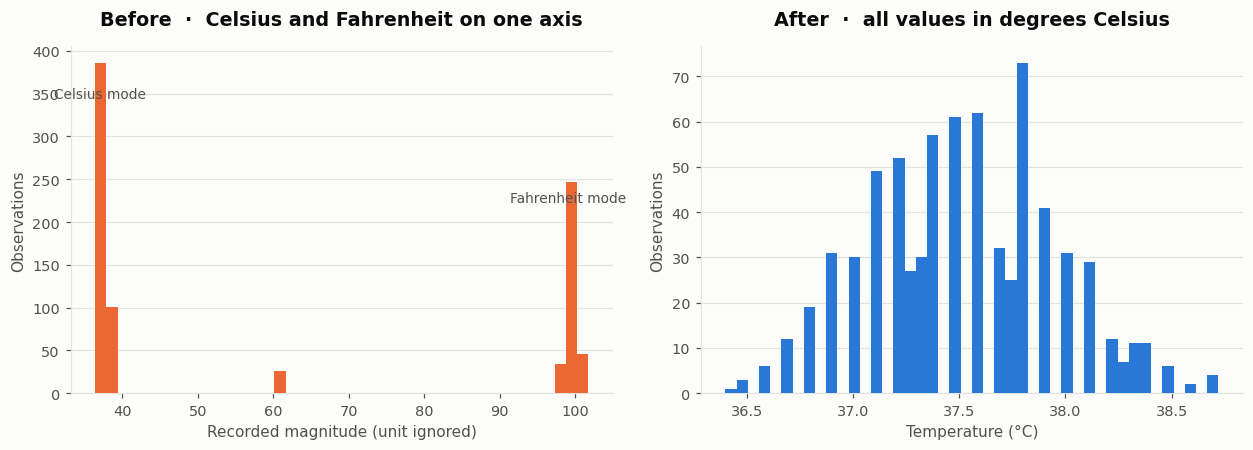

In [19]:
fig = plots.plot_temperature_unit_problem(
    raw_values=raw_temperature_magnitude,
    converted_values=cleaned["temperature"],
)
plt.show()

The left panel is bimodal; the right is unimodal and centred where human body temperature
belongs. The two modes on the left were never two patient populations.

Note that the "after" panel still contains a small number of values outside the plausible
range — those are the deliberately injected impossible readings. Rejecting them is the
*next* tool's job, not this one's, and keeping that boundary clean is what stops a "repair"
from converting nonsense into different nonsense.

---
## 10. Categorical vocabulary and physiological ranges

### 10.1 Controlled vocabulary

`Emergency`, `emergency`, `ER` and `Emergency Admission` are one admission type recorded by
four people. Left alone they become four one-hot columns, splitting the statistical power
of the cohort across spellings and making a model's coefficients uninterpretable.

The mapping is **explicit, not fuzzy**. Anything outside the controlled vocabulary is
reported as unmapped rather than silently guessed. Fuzzy matching is tempting here and
wrong: in a clinical setting, quietly mapping an unrecognised diagnosis onto the nearest
known one invents a fact about a patient.

In [20]:
categorical_audit = result.audits["standardise_categories"]

rows = []
for column, detail in categorical_audit.items():
    rows.append({
        "column": column,
        "distinct before": detail["distinct_before"],
        "distinct after": detail["distinct_after"],
        "cells rewritten": f"{detail['cells_changed']:,}",
        "unmapped": len(detail["unmapped_values"]),
        "canonical values": ", ".join(detail["values_after"][:5]),
    })
display(pd.DataFrame(rows))

print("Example — admission_type")
print(f"  before: {categorical_audit['admission_type']['values_before']}")
print(f"  after : {categorical_audit['admission_type']['values_after']}")

,column,distinct before,distinct after,cells rewritten,unmapped,canonical values
0,gender,8,2,266,0,"Female, Male"
1,ethnicity,7,3,294,0,"African, African-American, Other"
2,admission_type,11,4,268,0,"Emergency, ICU, Outpatient, Ward"
3,diagnosis,13,5,275,0,"Cardiac Failure, Pneumonia, Sepsis, Stroke, Tr..."
4,medication,13,5,266,0,"Antibiotic, Insulin, No Medication, Sedative, ..."
5,data_source,9,3,259,0,"Laboratory, Monitor, Nurse Entry"


Example — admission_type
  before: ['ER', 'Emergency', 'Emergency Admission', 'ICU', 'ICU transfer', 'Outpatient', 'Ward', 'emergency', 'icu', 'outpatient', 'ward']
  after : ['Emergency', 'ICU', 'Outpatient', 'Ward']


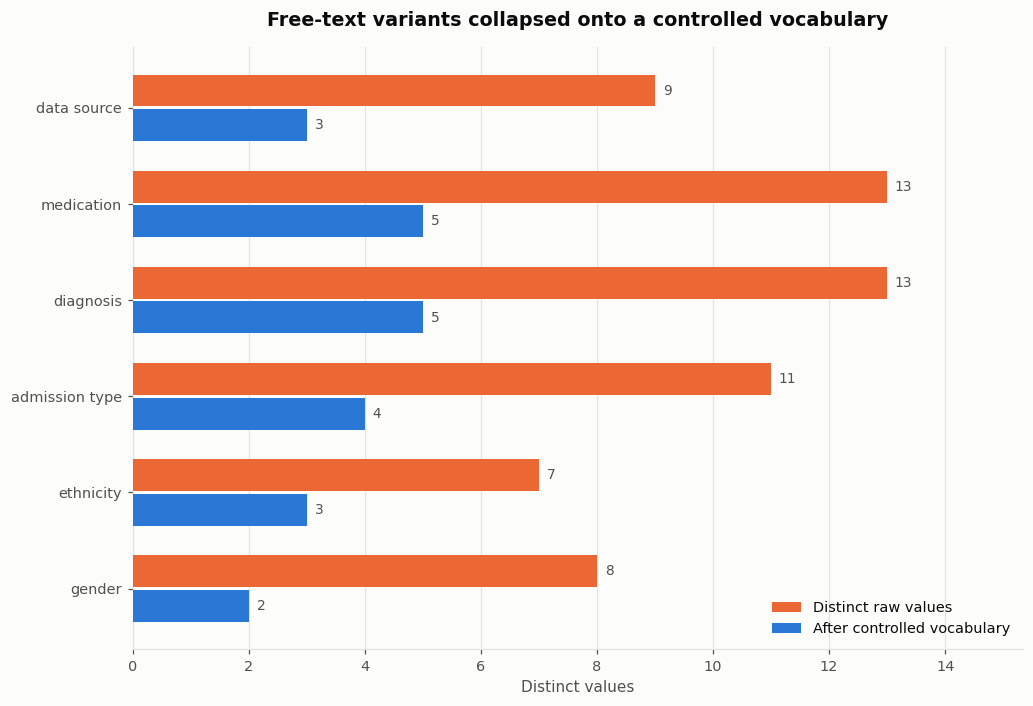

In [21]:
fig = plots.plot_category_consolidation(categorical_audit)
plt.show()

### 10.2 Physiological plausibility

A heart rate of 480 bpm and a saturation of 140% are not outliers. They are sensor faults
or transcription errors, and the honest representation of a faulty sensor reading is
**absent data**.

The critical design decision is that rejection **blanks the cell rather than dropping the
row**. In an irregularly sampled record each row carries several channels; discarding the
row because one channel is corrupt throws away the valid measurements recorded at the same
instant. Every rejected cell is logged with its admission, chart time, channel and value,
so the decision is fully reversible.

In [22]:
range_audit = result.audits["validate_ranges"]

rows = []
for column, detail in range_audit["by_column"].items():
    if detail["rejected"]:
        rows.append({
            "channel": column,
            "allowed range": f"{detail['allowed_range'][0]} – {detail['allowed_range'][1]}",
            "out of range": detail["out_of_range"],
            "unparseable text": detail["unparseable_text"],
            "observed before": f"{detail['observed_before']:,}",
            "observed after": f"{detail['observed_after']:,}",
        })
display(pd.DataFrame(rows))

print(f"Total cells rejected : {range_audit['total_cells_rejected']:,}")
print(f"Rows dropped         : 0   (policy: {range_audit['policy']})")

print("\nSample of the rejection log:")
display(pd.DataFrame(range_audit["rejections"][:6]))

,channel,allowed range,out of range,unparseable text,observed before,observed after
0,age,0.0 – 120.0,22,0,844,822
1,heart_rate,20.0 – 250.0,39,0,749,710
2,sbp,50.0 – 250.0,48,0,722,674
3,dbp,20.0 – 150.0,26,0,713,687
4,mbp,30.0 – 180.0,45,0,766,721
5,temperature,30.0 – 43.0,40,0,764,724
6,spo2,50.0 – 100.0,53,0,801,748
7,resp_rate,4.0 – 60.0,35,0,754,719
8,glucose,20.0 – 600.0,20,0,706,686


Total cells rejected : 328
Rows dropped         : 0   (policy: cell_set_to_missing__row_retained)

Sample of the rejection log:


,row_index,admission_id,charttime,column,value,reason
0,6,ADM0011,2026-01-17 07:27:00,age,-5.0,out_of_physiological_range
1,41,ADM0004,2026-02-13 18:33:00,age,-5.0,out_of_physiological_range
2,81,ADM0072,2026-01-07 20:24:00,age,150.0,out_of_physiological_range
3,119,ADM0077,2026-01-23 13:38:00,age,-5.0,out_of_physiological_range
4,287,ADM0074,2026-01-16 17:27:00,age,150.0,out_of_physiological_range
5,330,ADM0018,2026-02-03 08:30:00,age,-5.0,out_of_physiological_range


---
## 11. From events to hours - where missingness becomes visible

This is the conceptual centre of the pipeline.

The raw table records *when somebody happened to measure something*. A model needs *what
the patient's state was at each hour*. Those are different objects, and converting between
them is where clinical missingness acquires its meaning.

An admission spanning $[t_{\text{in}}, t_{\text{out}}]$ is expanded onto the hourly grid

$$
\mathcal{H} = \left\{\, \lfloor t_{\text{in}} \rfloor_{1\text{h}} + k \cdot 1\,\text{h} \;:\; k = 0, 1, \ldots, K \,\right\},
\qquad
K = \left\lceil \frac{t_{\text{out}} - t_{\text{in}}}{1\,\text{h}} \right\rceil
$$

Each observation is assigned to the hour bin containing its chart time. Where two
observations share a bin they are averaged; where no observation falls in a bin, the cell
is **genuinely missing** — not because somebody forgot to record it, but because nothing
was measured during that hour.

,value
event rows in,900
hourly rows out,"4,715"
expansion,5.24x
admissions,100
observations merged into a shared hour,89
hours per admission (min / median / max),25 / 47.5 / 72


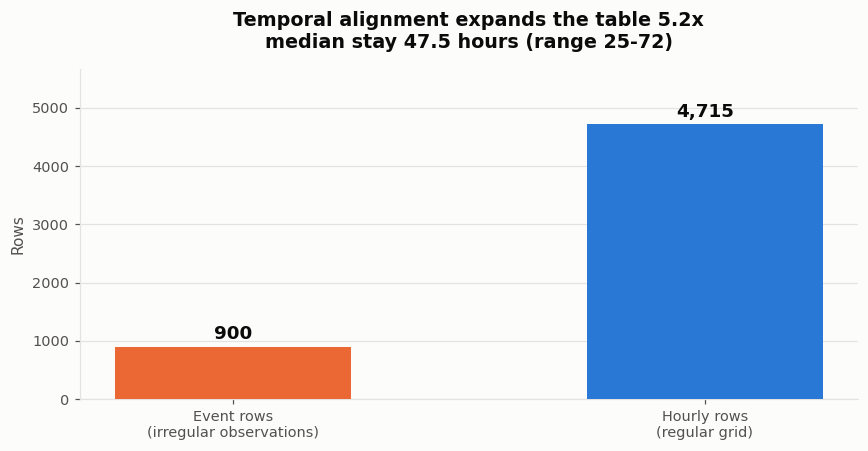

In [23]:
hourly_audit = result.audits["build_hourly_timeseries"]

display(pd.DataFrame([{
    "event rows in": f"{hourly_audit['rows_before']:,}",
    "hourly rows out": f"{hourly_audit['rows_after']:,}",
    "expansion": f"{hourly_audit['expansion_factor']}x",
    "admissions": hourly_audit["admissions"],
    "observations merged into a shared hour": hourly_audit["observations_merged_into_shared_hour"],
    "hours per admission (min / median / max)": (
        f"{hourly_audit['hours_per_admission']['min']} / "
        f"{hourly_audit['hours_per_admission']['median']} / "
        f"{hourly_audit['hours_per_admission']['max']}"
    ),
}]).T.rename(columns={0: "value"}))

fig = plots.plot_timeseries_expansion(
    hourly_audit["rows_before"], hourly_audit["rows_after"], hourly_audit["hours_per_admission"]
)
plt.show()

### 11.1 The number that changes the story

In [24]:
comparison = pd.DataFrame({
    "raw event table (%)": pd.Series(hourly_audit["missing_pct_before"]),
    "after hourly alignment (%)": pd.Series(hourly_audit["missing_pct_after"]),
})
comparison["increase (pp)"] = (
    comparison["after hourly alignment (%)"] - comparison["raw event table (%)"]
).round(1)
display(comparison.round(1))

mean_before = comparison["raw event table (%)"].mean()
mean_after = comparison["after hourly alignment (%)"].mean()
print(f"Mean missingness before alignment : {mean_before:.1f}%")
print(f"Mean missingness after alignment  : {mean_after:.1f}%")

,raw event table (%),after hourly alignment (%),increase (pp)
heart_rate,21.1,86.2,65.0
sbp,25.1,86.9,61.8
dbp,23.7,86.6,62.9
mbp,19.9,86.1,66.2
temperature,19.6,85.8,66.3
spo2,16.9,85.3,68.4
resp_rate,20.1,86.1,66.0
glucose,23.8,86.6,62.9


Mean missingness before alignment : 21.3%
Mean missingness after alignment  : 86.2%


Alignment **raises** measured missingness, by a very large margin. Nothing was lost — the
event layout was concealing every hour in which nothing was recorded.

This matters for how the project is judged. Reading only the raw and final figures would
suggest the pipeline solved a 17% problem. It actually solved an 86% one. A pipeline that
reported "17% missing, now 0%" would be describing a different and much easier dataset than
the one it was given.

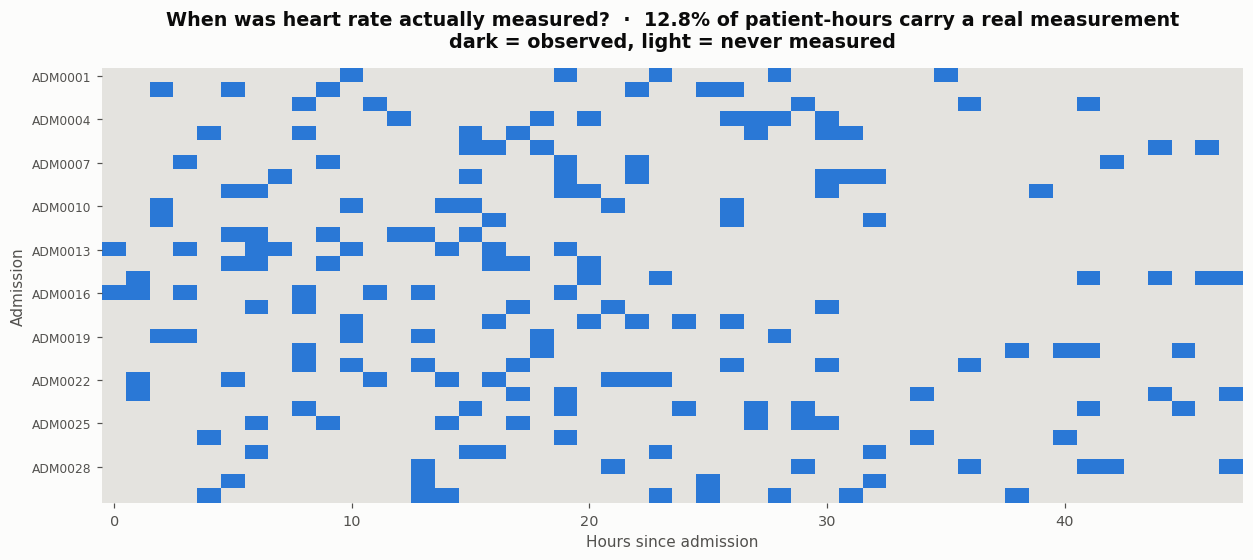

Each row is an admission, each column an hour. Dark cells are real measurements.
The sparsity is the clinical reality: measurement is a decision, not a schedule.


In [25]:
fig = plots.plot_missingness_heatmap(result.processed, channel="heart_rate", n_admissions=30, hours=48)
plt.show()

print("Each row is an admission, each column an hour. Dark cells are real measurements.")
print("The sparsity is the clinical reality: measurement is a decision, not a schedule.")

---
## 12. Value, Mask and Decay

### 12.1 Why plain imputation is not enough

Filling a gap with the last observed value produces a table a model can consume, and
destroys the information that the cell was ever empty. In intensive care that information
is clinically loaded: a patient measured every fifteen minutes is being watched closely,
and one measured twice a day is stable. **Missingness is not noise to be removed — it is a
signal about the patient.**

Each channel $x$ is therefore expanded into three aligned series.

**Value** - the carried-forward series:

$$
v_t = \begin{cases} x_t, & x_t \text{ observed} \\ v_{t-1}, & \text{otherwise} \end{cases}
$$

**Mask** - the provenance indicator:

$$
m_t = \begin{cases} 1, & x_t \text{ genuinely observed} \\ 0, & x_t \text{ imputed} \end{cases}
$$

**Decay** - the confidence weight:

$$
d_t = \gamma^{\,j_t}, \qquad \gamma = 0.75
$$

where $j_t$ is the number of hours since the most recent genuine observation, so $j_t = 0$
whenever $m_t = 1$. A value carried forward one hour keeps weight $0.75$; after six hours
it retains $0.75^{6} \approx 0.18$. The model is told not only *what* the value is, but
*how much to believe it* — the same intuition GRU-D formalises for clinical time series.

### 12.2 Leading gaps and neutral fill

Before a channel's first observation there is nothing to carry forward, so LOCF is
undefined. Those cells receive the population mean $\mu$, computed over genuinely observed
values only. After standardisation

$$
z = \frac{x - \mu}{\sigma}
$$

a neutral-filled cell becomes **exactly zero** - the "no information" point of the
standardised scale - while its mask stays $0$ and its decay stays near the floor, so the
fill is never mistaken for evidence.

The statistics deliberately exclude imputed cells. Including them would let the fill value
drag the mean towards itself, and the guarantee would quietly stop holding.

In [26]:
from preprocessing.missing_value_handler import locf_with_mask_and_decay

worked = locf_with_mask_and_decay(pd.Series([80.0, np.nan, np.nan, 85.0]), population_mean=75.0)
display(pd.DataFrame({
    "hour": ["10:00", "11:00", "12:00", "13:00"],
    "raw": [80.0, np.nan, np.nan, 85.0],
    "Value": worked["value"],
    "Mask": worked["mask"],
    "Decay": np.round(worked["decay"], 4),
    "gap j": worked["gap_hours"],
    "fill kind": worked["fill_kind"],
}))

print("Decay follows 0.75^j exactly:", np.allclose(worked["decay"], [1.0, 0.75, 0.5625, 1.0]))

,hour,raw,Value,Mask,Decay,gap j,fill kind
0,10:00,80.0,80.0,1,1.0000,0,observed
1,11:00,NaN,80.0,0,0.7500,1,locf
2,12:00,NaN,80.0,0,0.5625,2,locf
3,13:00,85.0,85.0,1,1.0000,0,observed


Decay follows 0.75^j exactly: True


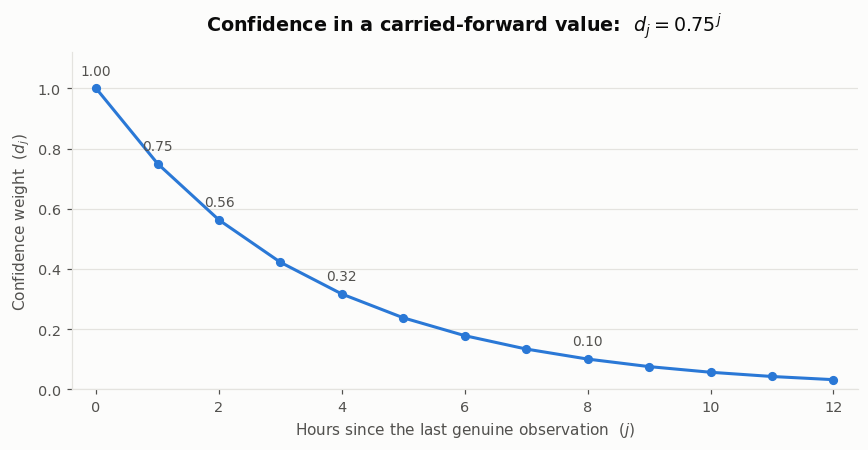

In [27]:
fig = plots.plot_decay_curve()
plt.show()

In [28]:
vmd_audit = result.audits["build_value_mask_decay"]

channel_table = pd.DataFrame(vmd_audit["channels"]).T
channel_table = channel_table[["observed", "locf_filled", "neutral_filled", "observed_pct",
                                "max_gap_hours", "mean_decay_on_imputed"]]
display(channel_table)

print("Neutral-fill guarantee — largest |z| among neutral-filled cells (must be ~0):")
for channel, worst in vmd_audit["neutral_fill_zero_check"].items():
    print(f"    {channel:<14} {worst}")

,observed,locf_filled,neutral_filled,observed_pct,max_gap_hours,mean_decay_on_imputed
heart_rate,653.0,3481.0,581.0,13.85,44.0,0.3253
sbp,619.0,3473.0,623.0,13.13,40.0,0.3204
dbp,634.0,3509.0,572.0,13.45,43.0,0.3239
mbp,655.0,3500.0,560.0,13.89,36.0,0.3296
temperature,667.0,3536.0,512.0,14.15,36.0,0.3312
spo2,691.0,3526.0,498.0,14.66,36.0,0.3415
resp_rate,655.0,3474.0,586.0,13.89,45.0,0.3289
glucose,630.0,3557.0,528.0,13.36,40.0,0.3261


Neutral-fill guarantee — largest |z| among neutral-filled cells (must be ~0):
    heart_rate     0.0
    sbp            0.0
    dbp            0.0
    mbp            0.0
    temperature    0.0001
    spo2           0.0001
    resp_rate      0.0
    glucose        0.0


That last block is not decoration. The claim "a neutral-filled cell standardises to zero"
is checked empirically against the data rather than asserted in prose, and the agent's
postcondition check fails the run if it stops holding.

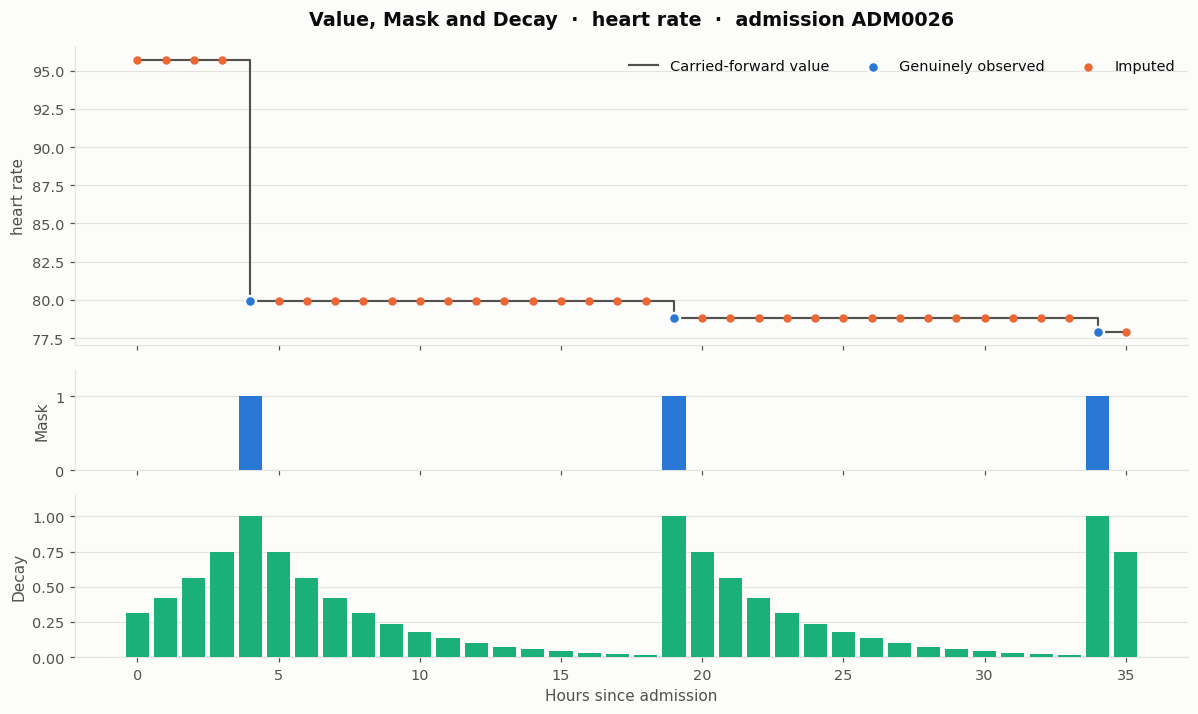

In [29]:
fig = plots.plot_value_mask_decay_example(result.processed, channel="heart_rate")
plt.show()

Read the three panels together. The top shows the carried-forward trajectory with genuine
observations marked. The middle shows the mask — a handful of ones in a field of zeros.
The bottom shows decay spiking to $1$ at each real observation and falling away between
them. Before the first observation, the flat segment at the population mean is the neutral
fill, and its decay sits near the floor: the representation is saying "this is a guess, and
a weak one".

---
## 13. DeepTSE-inspired refinement

### 13.1 What this is, and what it is not

This is **not** a re-implementation of a published deep time-series encoder. Training a
recurrent imputation network on a hundred admissions would overfit, take minutes on stage,
and prove nothing. What is reproduced is the *mechanism* that makes such models work, in a
form that runs in under a second, is deterministic, and can be read end to end:

1. a **temporal embedding** carrying the Value–Mask–Decay triple rather than the value
   alone;
2. a **cross-channel refiner** predicting a channel from the simultaneous state of the
   others, because vital signs are physiologically coupled;
3. a **decay-gated blend** between the carried-forward value and the model prediction.

The blend is the heart of it. For an imputed cell with gap $j$ and decay $d = \gamma^{j}$:

$$
\hat{x} = d \cdot v_{\text{LOCF}} \;+\; (1 - d) \cdot f_{\theta}(\mathbf{h})
$$

One hour after a real measurement $d = 0.75$ and the carried value dominates — correctly,
since the patient has barely changed. Eight hours later $d \approx 0.10$ and the estimate
has drifted to what the other channels imply.

### 13.2 The inviolable rule

$$
\hat{x}_t = \begin{cases} x_t, & m_t = 1 \quad \text{(observed — never touched)} \\[2pt] d_t v_t + (1 - d_t) f_\theta(\mathbf{h}_t), & m_t = 0 \end{cases}
$$

A genuinely observed measurement is evidence. Overwriting it with a model's opinion would
be data fabrication, and in a clinical dataset that is not a technical error but an ethical
one. The rule is enforced in code and then *verified independently* in §14.

### 13.3 Training it honestly

Fitting the refiner on observed cells directly is the obvious approach and it is **wrong**.
At an observed cell the channel's own feature *is* the target, so the regression achieves a
perfect in-sample fit by copying one column, learns nothing, and at imputation time merely
echoes LOCF. The training distribution has to match the inference distribution.

The remedy is the standard self-supervised construction: hide a random subset of genuinely
observed cells, rebuild the representation as though those measurements had never been
taken, and fit on the hidden cells — where the context looks exactly like an imputed cell
and the truth is nonetheless known.

In [30]:
refinement_audit = result.audits["refine_missing_values"]

print(f"Method     : {refinement_audit['method']}")
print(f"Blend      : {refinement_audit['blend_formula']}")
print(f"Refined    : {refinement_audit['cells_refined']:,} imputed cells")
print(f"Protected  : {refinement_audit['cells_protected_observed']:,} observed cells")
print(f"Observed cells modified : {refinement_audit['observed_cells_modified']}  (must be 0)\n")

training = pd.DataFrame(refinement_audit["training_report"]).T
display(training)

Method     : decay_gated_ridge_refinement
Blend      : x_hat = decay * locf + (1 - decay) * cross_channel_prediction
Refined    : 32,516 imputed cells
Protected  : 5,204 observed cells
Observed cells modified : 0  (must be 0)



,training_rows,n_features,r2_in_sample,training_scheme,mask_fraction
heart_rate,163,43,0.8537,self_supervised_artificial_masking,0.25
sbp,155,43,0.8208,self_supervised_artificial_masking,0.25
dbp,158,43,0.8806,self_supervised_artificial_masking,0.25
mbp,164,43,0.8353,self_supervised_artificial_masking,0.25
temperature,167,43,0.7502,self_supervised_artificial_masking,0.25
spo2,173,43,0.8279,self_supervised_artificial_masking,0.25
resp_rate,164,43,0.82,self_supervised_artificial_masking,0.25
glucose,158,43,0.5299,self_supervised_artificial_masking,0.25


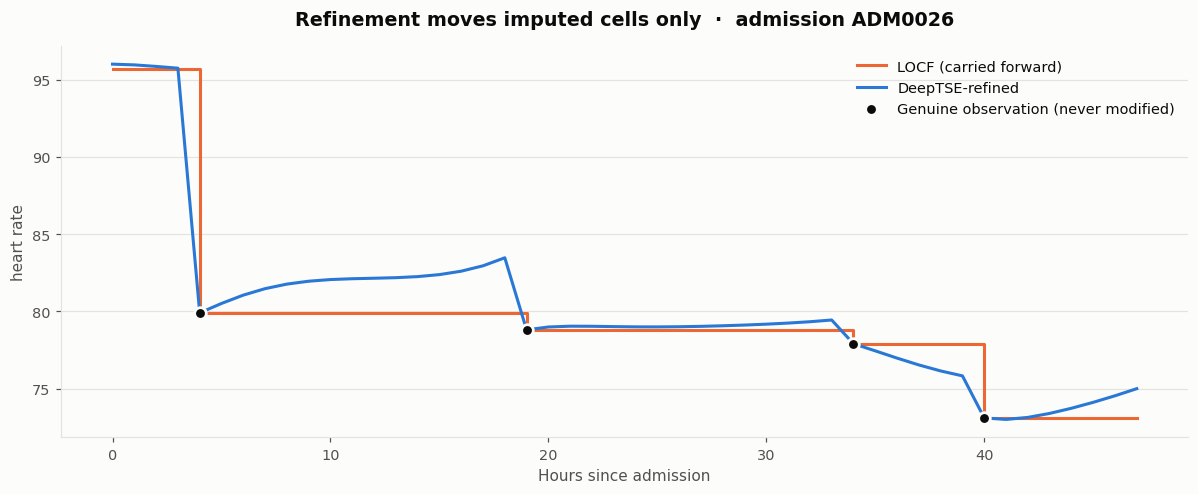

In [31]:
fig = plots.plot_patient_trajectory(result.processed, channel="heart_rate")
plt.show()

The two lines coincide **exactly** at every observed point - that is the guarantee being
illustrated - and separate only across gaps, by an amount governed by the decay weight.

### 13.4 Does it actually help?

This is the question most demonstrations skip. The honest way to answer it is to hide
genuinely observed cells, rebuild the representation without them, run both estimators, and
score each against what was withheld.

The *shape* of the holdout matters more than it looks:

- **Random holdout** hides isolated observations. The hidden cell is usually bracketed by
  measurements an hour away, so LOCF is already close to optimal and no method has much
  room to win.
- **Block holdout** hides runs of consecutive observations, simulating a monitoring outage
  or a handover gap. This is the regime imputation is actually deployed in.

In [32]:
from models.deeptse_imputer import benchmark_against_locf

benchmark_random = benchmark_against_locf(result.hourly, holdout_mode="random")
benchmark_block = benchmark_against_locf(result.hourly, holdout_mode="block")

display(pd.DataFrame([
    {"holdout": "random (isolated cells)", **benchmark_random["overall"]},
    {"holdout": "block (multi-hour outage)", **benchmark_block["overall"]},
]).set_index("holdout"))

,held_out_cells,locf_standardised_mae,deeptse_standardised_mae,improvement_pct,channels_improved,channels_tested
holdout,,,,,,
random (isolated cells),780,0.4117,0.4076,1.00,5,8
block (multi-hour outage),757,0.4835,0.4551,5.87,5,8


,held-out cells,LOCF MAE,DeepTSE MAE,improvement (%)
mbp,98.0,4.4426,3.1992,27.99
sbp,86.0,5.6085,4.6410,17.25
dbp,95.0,3.3779,3.1246,7.50
heart_rate,96.0,5.8684,5.5474,5.47
temperature,91.0,0.1939,0.1906,1.73
resp_rate,97.0,1.1299,1.1777,-4.23
glucose,92.0,11.1670,11.7296,-5.04
spo2,102.0,0.7895,0.8516,-7.86


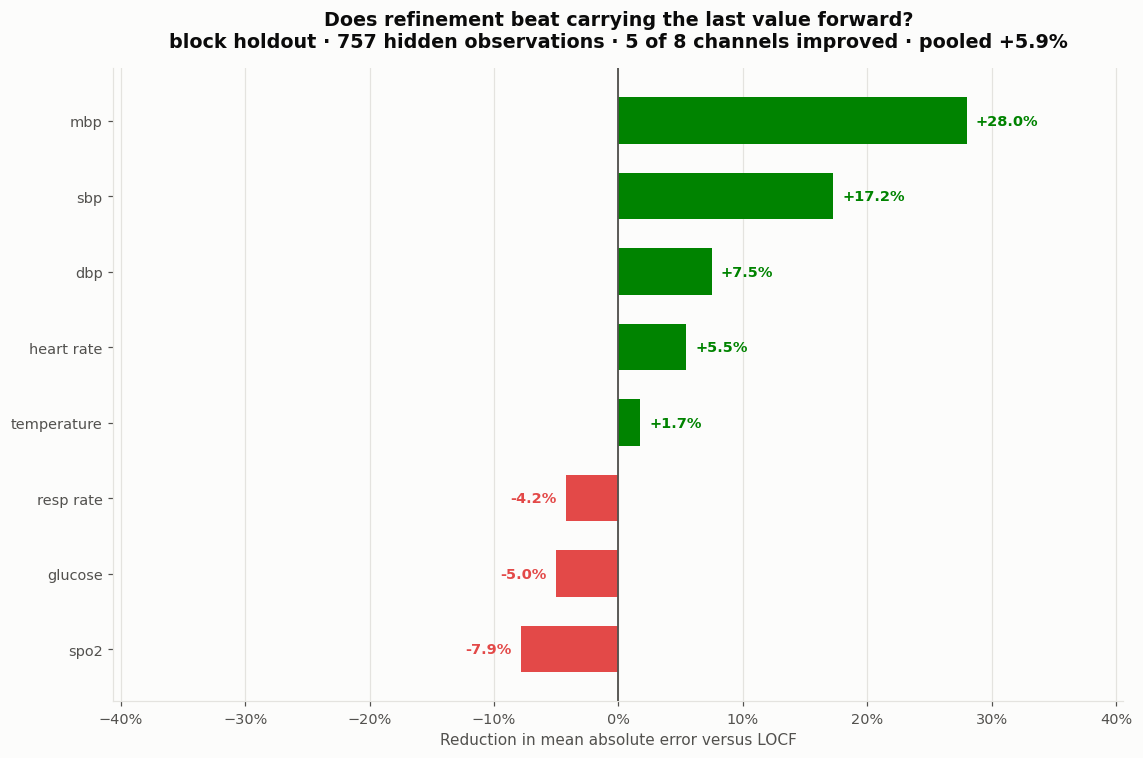

In [33]:
detail = pd.DataFrame(benchmark_block["by_channel"]).T
detail = detail[["held_out_cells", "locf_mae", "deeptse_mae", "mae_improvement_pct"]]
detail.columns = ["held-out cells", "LOCF MAE", "DeepTSE MAE", "improvement (%)"]
display(detail.sort_values("improvement (%)", ascending=False))

fig = plots.plot_imputation_benchmark(benchmark_block)
plt.show()

### 13.5 Reading the result honestly

The pooled improvement under a realistic block holdout is positive but modest, and **three
of the eight channels get worse**. That is the finding, and it is reported rather than
buried.

It is also interpretable. The channels that improve most — mean and systolic blood
pressure — are the ones most strongly coupled to their neighbours, so a cross-channel
prediction genuinely adds information. The channels that degrade are weakly coupled to the
rest, and for those the carried-forward value was already the best available estimate.

The defensible conclusion is therefore not "use DeepTSE refinement". It is:

> **Benchmark imputation per channel, and ship the simpler method wherever it wins.**

If this notebook reported a uniform improvement, that would be evidence of a leak in the
evaluation rather than a triumph of the method.

---
## 14. The validation agent

### 14.1 Why a second agent

The preprocessing agent checks its own work step by step. That is necessary and not
sufficient: a component that grades itself shares its own blind spots.

The validation agent re-derives every claim **from the data**, not from the audits, and
reports each as an assertion that either holds or does not. It answers the four questions a
reviewer would actually ask:

1. *Did the agent do what it said?* Row, duplicate and null counts are recomputed from the
   raw and final tables and compared against the reported figures.
2. *Is the output internally sound?* Masks binary, decays in $[0,1]$, hourly grid
   contiguous, no channel still holed.
3. *Was anything fabricated?* Every observed cell is compared against its pre-refinement
   value. A single difference fails the run.
4. *Is it reproducible?* Schema, standardisation statistics and seed are recorded.

**This is not hypothetical.** During development, the independent check caught a defect the
agent's own postcondition missed: inverting the $z$-transform introduced rounding of order
$10^{-4}$, which perturbed observed values even though the refinement logic had left them
alone. The agent's self-check operated on the standardised scale and saw nothing wrong. The
independent check recomputed from the final table and failed two channels. The fix was to
copy observed cells through verbatim rather than round-trip them.

In [34]:
from agents.validation_agent import build_validation_report, write_html_summary

report = build_validation_report(
    raw, result, benchmark=benchmark_block, ground_truth=GROUND_TRUTH
)
summary_path = write_html_summary(report)

verdict = report["verdict"]
print(f"VERDICT   : {'PASSED' if verdict['passed'] else 'FAILED'}")
print(f"Assertions: {verdict['assertions_total'] - verdict['assertions_failed']}/{verdict['assertions_total']} passed")
print(f"Statement : {verdict['statement']}")
if verdict["failed_assertions"]:
    print(f"Failed    : {verdict['failed_assertions']}")

print(f"\nWritten: {config.VALIDATION_REPORT_JSON.name}, {summary_path.name}")

VERDICT   : PASSED
Assertions: 52/52 passed
Statement : All assertions hold. The cleaned dataset matches every claim made about it.

Written: validation_report.json, cleaning_summary.html


In [35]:
assertions = pd.DataFrame(report["assertions"])
assertions["result"] = np.where(assertions["passed"], "PASS", "FAIL")
display(assertions[["result", "name", "expected", "observed"]].head(20))
print(f"... {len(assertions)} assertions in total")

,result,name,expected,observed
0,PASS,row_count_after_deduplication_matches_audit,900,900
1,PASS,no_duplicate_rows_remain,0,0
2,PASS,every_admission_survived_cleaning,100,100
3,PASS,all_lengths_of_stay_positive,> 0 hours,24.0
4,PASS,age_within_physiological_range,0,0
5,PASS,heart_rate_within_physiological_range,0,0
6,PASS,sbp_within_physiological_range,0,0
7,PASS,dbp_within_physiological_range,0,0
8,PASS,mbp_within_physiological_range,0,0
9,PASS,temperature_within_physiological_range,0,0


... 52 assertions in total


### 14.2 Before and after

In [36]:
before_stats, after_stats, records = (
    report["original_statistics"], report["final_statistics"], report["records"]
)

display(pd.DataFrame({
    "metric": ["Rows", "Columns", "Admissions", "Duplicate rows",
               "Distinct datetime formats", "Columns with mixed units"],
    "before": [f"{before_stats['rows']:,}", before_stats["columns"], before_stats["admissions"],
               f"{before_stats['duplicate_rows']:,}",
               max(before_stats["distinct_datetime_formats"].values()),
               len(before_stats["columns_with_mixed_units"])],
    "after": [f"{after_stats['hourly_rows']:,} hourly ({after_stats['event_rows']:,} events)",
              after_stats["columns"], after_stats["admissions"],
              f"{after_stats['duplicate_rows']:,}",
              after_stats["distinct_datetime_formats"],
              len(after_stats["columns_with_mixed_units"])],
}))

,metric,before,after
0,Rows,"1,000","4,715 hourly (900 events)"
1,Columns,24,116
2,Admissions,100,100
3,Duplicate rows,100,0
4,Distinct datetime formats,4,1
5,Columns with mixed units,4,0


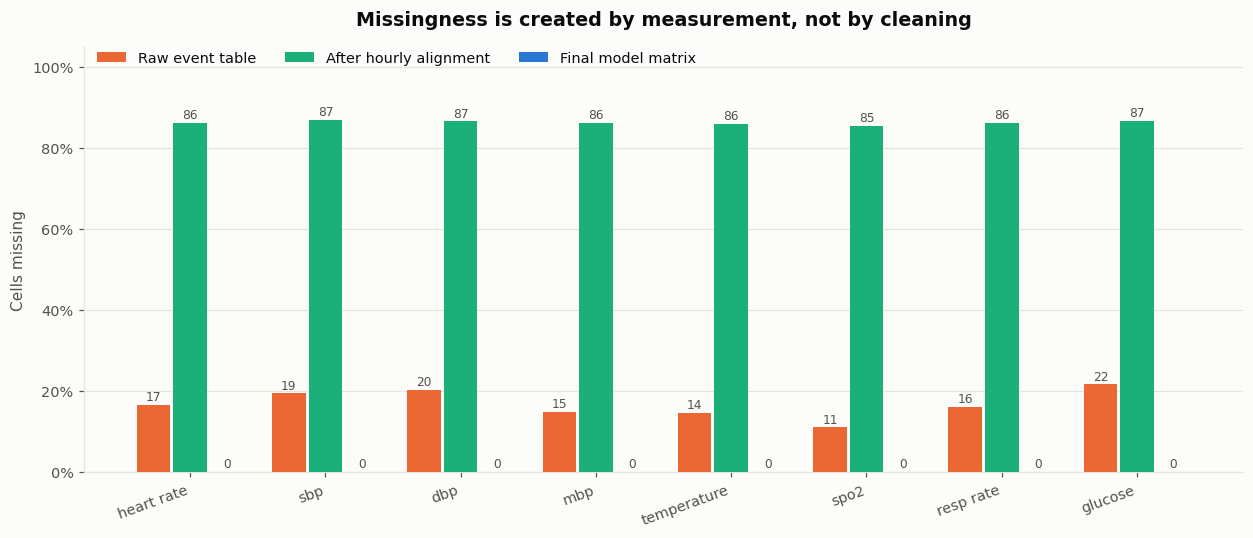

In [37]:
missing = report["missing_values"]
fig = plots.plot_missingness_before_after(
    missing["raw_event_level_pct"],
    missing["hourly_before_imputation_pct"],
    missing["after_imputation_pct"],
)
plt.show()

### 14.3 Defect recovery against ground truth

Because the dataset is synthetic, the pipeline can be scored against defects known to have
been injected. No real dataset permits this, and it is the strongest single argument for
demonstrating on synthetic data.

In [38]:
if "defect_recovery" in report:
    recovery = report["defect_recovery"]
    print(recovery["note"], "\n")
    display(pd.DataFrame([
        {"defect": "Duplicate rows",
         "injected": recovery["duplicate_rows"]["injected"],
         "recovered": recovery["duplicate_rows"]["recovered"],
         "rate": f"{recovery['duplicate_rows']['recovery_rate_pct']}%"},
        {"defect": "Fahrenheit temperatures",
         "injected": recovery["fahrenheit_temperatures"]["injected"],
         "recovered": recovery["fahrenheit_temperatures"]["recovered_after_deduplication"],
         "rate": "see note"},
        {"defect": "Categorical variant cells",
         "injected": recovery["categorical_variant_cells"]["injected"],
         "recovered": recovery["categorical_variant_cells"]["cells_rewritten"],
         "rate": "see note"},
    ]))
    unmapped = recovery["unmapped_category_values"]
    print(f"\nUnmapped category values: {unmapped if unmapped else 'none — the vocabulary covered every value'}")
else:
    print("Ground truth unavailable for this input file.")

Injected counts are measured on the 1000-row file as generated; recovered counts are measured after deduplication, so a defect that existed only inside a removed duplicate is correctly never seen again. 



,defect,injected,recovered,rate
0,Duplicate rows,100,100,100.0%
1,Fahrenheit temperatures,404,285,see note
2,Categorical variant cells,1819,1628,see note



Unmapped category values: none — the vocabulary covered every value


### 14.4 Persisting the outputs

In [39]:
result.cleaned_events.to_csv(config.CLEANED_CSV, index=False)
result.processed.to_csv(config.HOURLY_CSV, index=False)

for path in (config.CLEANED_CSV, config.HOURLY_CSV,
             config.VALIDATION_REPORT_JSON, config.CLEANING_SUMMARY_HTML,
             config.AGENT_TRACE_JSON):
    print(f"  {path.name:<34} {path.stat().st_size / 1024:8.1f} kB")

print("\nModel-ready matrix, first rows (heart rate):")
display(result.processed[[
    "admission_id", "hour", "hours_since_admission",
    "heart_rate_value", "heart_rate_mask", "heart_rate_decay", "heart_rate_refined",
]].head(12))

  cleaned_medical_data.csv              168.6 kB
  processed_hourly_timeseries.csv      2993.5 kB
  validation_report.json                 68.1 kB
  cleaning_summary.html                  12.0 kB
  agent_trace.json                       86.1 kB

Model-ready matrix, first rows (heart rate):


,admission_id,hour,hours_since_admission,heart_rate_value,heart_rate_mask,heart_rate_decay,heart_rate_refined
0,ADM0001,2026-01-09 06:00:00,0,95.699,0,0.056314,96.387
1,ADM0001,2026-01-09 07:00:00,1,95.699,0,0.075085,96.461
2,ADM0001,2026-01-09 08:00:00,2,95.699,0,0.100113,96.477
3,ADM0001,2026-01-09 09:00:00,3,95.699,0,0.133484,96.436
4,ADM0001,2026-01-09 10:00:00,4,95.699,0,0.177979,96.344
5,ADM0001,2026-01-09 11:00:00,5,95.699,0,0.237305,96.210
6,ADM0001,2026-01-09 12:00:00,6,95.699,0,0.316406,96.047
7,ADM0001,2026-01-09 13:00:00,7,95.699,0,0.421875,95.875
8,ADM0001,2026-01-09 14:00:00,8,95.699,0,0.562500,95.726
9,ADM0001,2026-01-09 15:00:00,9,95.699,0,0.750000,95.643


---
## 15. The dashboard

The dashboard is the *reviewer's* view. Where this notebook explains how each step works, it
shows only what happened and whether it can be trusted: headline numbers, before/after
comparisons, the assertion table, the agent trace, and a download of the model-ready data.

It reads exclusively from artefacts already on disk and never re-runs the pipeline. That
separation is deliberate — a dashboard that recomputes its own numbers can disagree with
the report, and then nobody knows which to believe.

```bash
streamlit run visualization/dashboard.py
```

In [40]:
dashboard_path = PROJECT_ROOT / "visualization" / "dashboard.py"
print(f"Dashboard  : {dashboard_path}")
print(f"Exists     : {dashboard_path.exists()}")
print(f"Reads      : {config.VALIDATION_REPORT_JSON.name}, {config.HOURLY_CSV.name}, "
      f"{config.CLEANED_CSV.name}, {config.AGENT_TRACE_JSON.name}")
print("\nLaunch with:  streamlit run visualization/dashboard.py")

Dashboard  : c:\Users\ADMIN\OneDrive\Desktop\Data Science\Projects\Medical_AI_Preprocessing_Agent\visualization\dashboard.py
Exists     : True
Reads      : validation_report.json, processed_hourly_timeseries.csv, cleaned_medical_data.csv, agent_trace.json

Launch with:  streamlit run visualization/dashboard.py


---
## 16. Limits, failure modes and responsible use

### 16.1 What happens when the plan is wrong

Everything above shows the agent succeeding. That is the least interesting case.

The tool catalogue declares that unit conversion must precede range validation. Run them
the other way round and every temperature is still a string — `"98.6 F"` — so the range
validator reads the whole column as unparseable text and rejects all of it.

Below, the agent is handed a deliberately mis-ordered plan. The failure is real, not
narrated.

**This section exists because the first version of this notebook got it wrong.** The
original postcondition for range validation asked *"are all remaining values inside the
physiological range?"* — and it **passed**, while every temperature reading in the dataset
was destroyed. An empty set has no offending members. The check was true and useless.

In [41]:
from agents.llm_planner import PlanStep


class DeliberatelyBrokenPlanner:
    # Validates ranges BEFORE converting units -- a genuine dependency violation.
    name = "deliberately_broken"

    def plan(self, profile):
        return [
            PlanStep("remove_duplicates", "Standard first step."),
            PlanStep("standardise_datetimes", "Standard second step."),
            PlanStep("validate_ranges", "MISTAKE: runs before units are canonical."),
            PlanStep("convert_units", "Too late — the Fahrenheit values are already gone."),
        ], ["This plan violates a declared tool precondition."]


broken_agent = PreprocessingAgent(planner=DeliberatelyBrokenPlanner(), verbose=True)

try:
    broken_result = broken_agent.run(raw, trace_path=None)
    halted = None
except RuntimeError as error:
    broken_result = None
    halted = error
    print("\n>>> The agent HALTED rather than writing out a corrupted dataset.")
    print(f">>> {error}")

AI MEDICAL PREPROCESSING AGENT

[PERCEIVE] Profiling the raw dataset ...
           1,000 rows x 24 columns | 100 duplicate rows | 4 columns with mixed units

[PLAN] Planner: deliberately_broken
       1. remove_duplicates
          why: Standard first step.
       2. standardise_datetimes
          why: Standard second step.
       3. validate_ranges
          why: MISTAKE: runs before units are canonical.
       4. convert_units
          why: Too late — the Fahrenheit values are already gone.
       ! concern: This plan violates a declared tool precondition.

[ACT 1/4] remove_duplicates
[OBSERVE] removed 100 duplicate rows (1,000 -> 900)
[VALIDATE] 1 check(s) passed

[ACT 2/4] standardise_datetimes
[OBSERVE] 4 spellings -> 1 | 336 cells would have been mis-parsed by naive parsing | median stay 46.0 h
[VALIDATE] 5 check(s) passed

[ACT 3/4] validate_ranges
[OBSERVE] 1,329 implausible cells set to missing (rows retained)
[VALIDATE] FAILED: no_channel_lost_the_majority_of_its_observati

In [42]:
from preprocessing.range_validator import validate_ranges
from preprocessing.duplicate_handler import remove_duplicates
from preprocessing.date_cleaner import standardise_datetimes

# Reproduce the damage directly, to quantify what the agent refused to accept.
broken_frame, _ = remove_duplicates(raw)
broken_frame, _ = standardise_datetimes(broken_frame)
broken_frame, broken_range_audit = validate_ranges(broken_frame)   # BEFORE convert_units

good_temperature = int(result.cleaned_events["temperature"].notna().sum())
broken_temperature = int(broken_frame["temperature"].notna().sum())

display(pd.DataFrame({
    "plan": ["correct order (convert, then validate)", "broken order (validate, then convert)"],
    "temperature readings surviving": [f"{good_temperature:,}", f"{broken_temperature:,}"],
    "lost": ["—", f"{good_temperature - broken_temperature:,}"],
}))

print("Channel loss under the broken plan:")
for channel, detail in broken_range_audit["by_column"].items():
    before_n, after_n = detail["observed_before"], detail["observed_after"]
    if before_n >= 20 and after_n / before_n < 0.5:
        print(f"    {channel:<14} {before_n:>5,} -> {after_n:>5,}   ({1 - after_n / before_n:.0%} destroyed)")

print(f"\nAgent halted: {halted is not None}")

,plan,temperature readings surviving,lost
0,"correct order (convert, then validate)",724,—
1,"broken order (validate, then convert)",0,724


Channel loss under the broken plan:
    temperature      764 ->     0   (100% destroyed)

Agent halted: True


### What the first version of the check missed

The range check passed. Every surviving value really was inside its physiological range —
because there were no surviving values. The column had been emptied, and an empty column
satisfies "all values in range" perfectly.

Data loss has to be checked for on its own terms, so a second postcondition was added:

> **No channel may lose the majority of its observations to a single validation pass.**

With that check in place the agent catches the violation immediately. And because there is
deliberately **no repair** for it — the measurements are already gone, and no later step
can recover them — the agent raises and stops.

Three points follow, and they are the most important in the notebook.

**A postcondition can be true and useless.** "Are all values valid?" is satisfied by
deleting everything. Pair every quality check with a coverage check, or you will validate
an empty table and call it clean.

**A repair is not a rescue.** Data destroyed by an earlier step cannot be recovered by a
later one. The only real defence is the ordering constraint declared up front.

**Repairs are enumerated, not generated.** An agent that invents a fix for an unanticipated
failure in clinical data is more dangerous than one that halts, because the failure it
improvises around is the one nobody reviewed. Halting is a feature.

### 16.2 When *not* to use an agent

| Situation | Better approach | Why |
|---|---|---|
| Fixed schema, known defects | Deterministic Python script | You already know the problem and the solution. An LLM adds latency, cost and nondeterminism for nothing. |
| High-throughput ingestion | Compiled pipeline with schema validation | Agent latency is measured in seconds; streaming budgets in milliseconds. |
| Data governed by strict residency rules | Local rule-based tooling only | Even a profile may be more than the governance regime permits to leave the building. |
| Safety-critical automated action | Human in the loop, always | No audit trail substitutes for a clinician's sign-off. |

The honest scope for agent-guided preprocessing is **exploration**: new sources, unknown
defects, the first hour of a project. Once the schema stabilises, freeze the plan the agent
produced into a deterministic script and keep the validation layer.

### 16.3 Security and privacy

- **Data locality.** Only the ~1.5 kB profile is used for reasoning. Rows never leave the
  machine, which is the property that makes this defensible for clinical data at all.
- **Closed action space.** The planner selects from eight declared tools. It cannot execute
  arbitrary code. A free-form CodeAct agent is more capable and requires sandboxing, an
  import allow-list and code review before execution.
- **Immutability of inputs.** No tool writes to the raw file. Outputs are new artefacts.
- **Auditability.** Every run writes a trajectory, a validation report and an HTML summary,
  including the original row index of every dropped row.
- **Re-identification.** A profile is aggregate, but small cohorts leak. For genuinely
  sensitive data, check cell counts before any summary leaves the building.

### 16.4 Summary of what was built

| | |
|---|---|
| Raw event rows | see table below |
| Duplicates removed | audited with original row indices |
| Silently mis-parsed dates avoided | counted against the naive parser |
| Units normalised | temperature to °C, glucose to mg/dL |
| Implausible cells rejected | logged individually, rows retained |
| Hourly rows generated | ~5x expansion |
| Representation | Value–Mask–Decay per channel |
| Refinement | decay-gated, observed cells never modified |
| Validation | independent assertions, all re-derived from data |

In [43]:
final = {
    "Raw event rows": f"{report['records']['input_rows']:,}",
    "Duplicate rows removed": f"{report['records']['duplicate_rows_removed']:,}",
    "Mis-parsed dates avoided": f"{result.audits['standardise_datetimes']['total_naive_parse_disagreements']:,}",
    "Fahrenheit temperatures converted": f"{result.audits['convert_units']['temperature']['converted_from_fahrenheit']:,}",
    "Category cells rewritten": f"{sum(d['cells_changed'] for d in categorical_audit.values()):,}",
    "Implausible cells rejected": f"{report['records']['cells_rejected_as_implausible']:,}",
    "Hourly rows generated": f"{report['records']['hourly_rows_generated']:,}",
    "Expansion factor": f"{report['records']['expansion_factor']}x",
    "Imputed cells refined": f"{refinement_audit['cells_refined']:,}",
    "Observed cells modified": refinement_audit["observed_cells_modified"],
    "Validation assertions passed": f"{verdict['assertions_total'] - verdict['assertions_failed']}/{verdict['assertions_total']}",
}
display(pd.DataFrame(final.items(), columns=["metric", "value"]))

print("\n" + "=" * 72)
print("An AI agent should not clean data by improvising. It should reason about")
print("the problem, execute controlled Python transformations, validate the results")
print("against conditions declared in advance, and leave a trail a human can check.")
print("=" * 72)

,metric,value
0,Raw event rows,"1,000"
1,Duplicate rows removed,100
2,Mis-parsed dates avoided,336
3,Fahrenheit temperatures converted,285
4,Category cells rewritten,"1,628"
5,Implausible cells rejected,328
6,Hourly rows generated,"4,715"
7,Expansion factor,5.24x
8,Imputed cells refined,"32,516"
9,Observed cells modified,0



An AI agent should not clean data by improvising. It should reason about
the problem, execute controlled Python transformations, validate the results
against conditions declared in advance, and leave a trail a human can check.


---
## Appendix A - Using a live LLM planner

The pipeline runs fully offline by default. To let a language model produce the plan:

```bash
pip install litellm
export GEMINI_API_KEY="..."        # or OPENAI_API_KEY / ANTHROPIC_API_KEY / GEMINI_API_KEY
```

```python
from agents.llm_planner import LLMPlanner
from agents.preprocessing_agent import PreprocessingAgent

agent = PreprocessingAgent(planner=LLMPlanner(model_name="gemini/gemini-2.5-flash"))
result = agent.run(raw)
```

The model receives the tool catalogue and the ~1.5 kB profile and returns JSON. Its output
is then **validated before anything runs**: unknown tool names are rejected and recorded as
concerns, and any ordering that violates a declared precondition is re-sorted into the
dependency-safe order. If nothing usable survives, the rule-based planner takes over and
the run continues.

That validation layer is the reusable idea. A plan is cheap to check and cheap to reject; a
transformation that has already run is neither.

---

*PyCon Kenya 2026 - "Building the Future with Python"*